In [2]:
!pip install torch_scatter torcheeg torch_geometric -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.1/295.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 47.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 58.8 MB/s e

In [ ]:


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64        # ✅ كان 16 — زودناه لـ 64
HEADS       = 4
DROPOUT     = 0.3       # ✅ كان 0.5 — قللناه
NUM_CLASSES = 4
IN_CHANNELS = 5         # DE bands
NUM_NODES   = 62        # EEG electrodes

EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-3
WD          = 1e-4
PATIENCE    = 20
THRESHOLD   = 0.5       # لبناء الـ graph من correlation

EMOTION_LABELS = ["Neutral", "Sad", "Fear", "Happy"]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — Fixed EEGGAT Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()

        self.dropout = dropout

        # ✅ Fix 1: hidden=64 بدل 16
        self.gat1 = GATConv(in_channels,   hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        # ✅ Fix 2: BatchNorm بعد كل layer
        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        # ✅ Fix 3: MLP classifier بدل FC واحدة
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        # Layer 1
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        # Layer 2
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        # Layer 3
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        # Global Pooling → vector واحد per graph
        x = global_mean_pool(x, batch)

        # Classifier
        return self.classifier(x)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — Graph Construction من Correlation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_edge_index(features: np.ndarray, threshold: float = THRESHOLD):
    """
    ✅ Fix 6: بنبني الـ graph من Pearson correlation بين الـ electrodes
    features: (N, 62, 5)
    Returns edge_index: (2, E)
    """
    # متوسط الـ features على كل الـ samples → (62, 5)
    mean_feat = features.mean(axis=0)                        # (62, 5)
    corr      = np.corrcoef(mean_feat)                       # (62, 62)
    corr      = np.nan_to_num(corr)

    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    print(f"Graph edges: {edge_index.shape[1]}  (threshold={threshold})")
    return edge_index


def make_pyg_dataset(features: np.ndarray,
                     labels:   np.ndarray,
                     edge_index: torch.Tensor):
    """
    حول كل sample لـ PyG Data object
    features: (N, 62, 5)
    """
    dataset = []
    for i in range(len(features)):
        data = Data(
            x          = torch.tensor(features[i], dtype=torch.float),  # (62, 5)
            edge_index = edge_index,
            y          = torch.tensor(labels[i],   dtype=torch.long)
        )
        dataset.append(data)
    return dataset



# ✅ الجديدة — صح
def collate_pyg(batch_list):
    # batch_list هي list of PyG Data objects مباشرةً
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels
    

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — Training Loop (Subject-Dependent)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
subject_results       = {}
all_preds_per_subject = {}
all_subjects          = sorted(dataset.info['subject_id'].unique())
meta_info             = dataset.info

print("Start Subject-Dependent Evaluation with EEG-GAT (Fixed)...")

for subject_id in all_subjects:
    print(f"\n{'='*30} Subject {subject_id} {'='*30}")

    subject_df = meta_info[meta_info['subject_id'] == subject_id].copy()
    indices    = subject_df.index.tolist()

    # ── Load Data ─────────────────────────────────────────────────────
    all_x, all_y = [], []
    for idx in indices:
        x, y = dataset[idx]
        all_x.append(x.squeeze())
        all_y.append(y)

    all_x = torch.stack(all_x).numpy()    # (N, 62, 5)
    all_y = np.array(all_y)

    # ── ✅ Fix 4: Normalize per subject ───────────────────────────────
    N, C, B    = all_x.shape
    scaler     = StandardScaler()
    all_x_norm = scaler.fit_transform(
                     all_x.reshape(N, -1)
                 ).reshape(N, C, B).astype(np.float32)

    # ── ✅ Fix 6: Build Graph from correlation ────────────────────────
    edge_index = build_edge_index(all_x_norm)

    # ── Train / Test Split ────────────────────────────────────────────
    train_idx, test_idx = train_test_split(
        np.arange(N), test_size=0.2,
        random_state=42, stratify=all_y
    )

    train_ds = make_pyg_dataset(all_x_norm[train_idx], all_y[train_idx], edge_index)
    test_ds  = make_pyg_dataset(all_x_norm[test_idx],  all_y[test_idx],  edge_index)

    # ── Weighted Sampler ──────────────────────────────────────────────
    y_train       = all_y[train_idx]
    class_counts  = np.bincount(y_train, minlength=4)
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in y_train]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_trues   = []
    best_preds   = []
    counter      = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):

        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch_graph, batch_labels in train_loader:
            batch_graph   = batch_graph.to(device)
            batch_labels  = batch_labels.to(device)

            optimizer.zero_grad()
            out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
            loss = criterion(out, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred        = out.argmax(dim=1)
            correct    += (pred == batch_labels).sum().item()
            total      += batch_labels.size(0)

        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        epoch_trues, epoch_preds = [], []

        with torch.no_grad():
            for batch_graph, batch_labels in test_loader:
                batch_graph  = batch_graph.to(device)
                batch_labels = batch_labels.to(device)

                out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
                pred = out.argmax(dim=1)

                val_correct += (pred == batch_labels).sum().item()
                val_total   += batch_labels.size(0)
                epoch_trues.extend(batch_labels.cpu().numpy())
                epoch_preds.extend(pred.cpu().numpy())

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {val_acc:.4f}")

        # ✅ Fix 5: Early Stopping + Save Best Model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_trues   = epoch_trues.copy()
            best_preds   = epoch_preds.copy()
            counter      = 0
            torch.save(model.state_dict(), f'best_gat_subject_{subject_id}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered")
                break

    print(f"Subject {subject_id} Best Acc: {best_val_acc*100:.2f}%")
    subject_results[subject_id]       = best_val_acc * 100
    all_preds_per_subject[subject_id] = (best_trues, best_preds)




In [ ]:




# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(subject_results.values())
print(f"\n{'='*50}")
print(f"  FINAL AVERAGE ACCURACY : {np.mean(all_accs):.2f}%")
print(f"  Std Accuracy           : {np.std(all_accs):.2f}%")
print(f"  Best  Subject          : Subject {max(subject_results, key=subject_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject          : Subject {min(subject_results, key=subject_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"  Detailed: {subject_results}")
print(f"{'='*50}")

In [ ]:
# ── Cell 2: Imports ──────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

from torcheeg.datasets import SEEDIVFeatureDataset
from torcheeg import transforms

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from torch.utils.data import DataLoader, random_split , WeightedRandomSampler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# ── Cell 3: Load Dataset ─────────────────────────────────────
dataset = SEEDIVFeatureDataset(
    io_path='./tmp_out/seed_iv_features',
    root_path='/kaggle/input/seed-iv/eeg_feature_smooth',
    feature=['de_LDS'],
    offline_transform=transforms.Compose([
        transforms.ToTensor()          # → shape (62, 5)  
    ]),
    label_transform=transforms.Select('emotion')
)

print(f"Total samples : {len(dataset)}")

# Quick check on one sample
sample_x, sample_y = dataset[0]
print(f"Feature shape : {sample_x.shape}")   # expected (62, 5) or (1, 62, 5)
print(f"Label sample  : {sample_y}")


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   EEG-GAT — Subject-Independent (LOSO)                              ║
# ║   SEED-IV | DE Features | 4 Classes | Leave-One-Subject-Out         ║
# ╚══════════════════════════════════════════════════════════════════════╝




# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
NUM_CLASSES = 4
IN_CHANNELS = 5
NUM_NODES   = 62

EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-3
WD          = 1e-4
PATIENCE    = 20
THRESHOLD   = 0.5

EMOTION_LABELS = ["Neutral", "Sad", "Fear", "Happy"]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — EEGGAT Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def load_subjects(subject_ids, meta_info, dataset):
    all_x, all_y = [], []
    for sid in subject_ids:
        subject_df = meta_info[meta_info['subject_id'] == sid]
        for idx in subject_df.index.tolist():
            x, y = dataset[idx]
            all_x.append(x.squeeze())
            all_y.append(y)
    all_x = torch.stack(all_x).numpy()
    all_y = np.array(all_y)
    return all_x, all_y


def build_edge_index(features, threshold=THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    return torch.tensor(np.stack([rows, cols]), dtype=torch.long)


def make_pyg_dataset(features, labels, edge_index):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        loss = criterion(out, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == batch_labels).sum().item()
        total      += batch_labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_trues, all_preds = [], []
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        pred = out.argmax(1)
        correct    += (pred == batch_labels).sum().item()
        total      += batch_labels.size(0)
        all_trues.extend(batch_labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
    return correct / total, all_trues, all_preds


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — LOSO Loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
meta_info    = dataset.info
all_subjects = sorted(dataset.info['subject_id'].unique())   # [1..15]

loso_results = {}   # {test_subject: best_acc}
loso_preds   = {}   # {test_subject: (trues, preds)}

print("=" * 60)
print("   LOSO — Leave-One-Subject-Out Evaluation")
print("=" * 60)

for test_sid in all_subjects:

    train_sids = [s for s in all_subjects if s != test_sid]

    print(f"\n{'─'*60}")
    print(f"  Test Subject : {test_sid}")
    print(f"  Train Subjects: {train_sids}")
    print(f"{'─'*60}")

    # ── Load ──────────────────────────────────────────────────────────
    train_x, train_y = load_subjects(train_sids,  meta_info, dataset)
    test_x,  test_y  = load_subjects([test_sid],  meta_info, dataset)

    # ── Normalize — fit على train بس ─────────────────────────────────
    N_tr, C, B = train_x.shape
    scaler     = StandardScaler()
    train_x_norm = scaler.fit_transform(
                       train_x.reshape(N_tr, -1)
                   ).reshape(N_tr, C, B).astype(np.float32)

    N_te = test_x.shape[0]
    test_x_norm = scaler.transform(
                      test_x.reshape(N_te, -1)
                  ).reshape(N_te, C, B).astype(np.float32)

    print(f"  Train: {N_tr} samples | Labels dist: {np.bincount(train_y)}")
    print(f"  Test : {N_te} samples | Labels dist: {np.bincount(test_y)}")

    # ── Graph — مبني من train بس ─────────────────────────────────────
    edge_index = build_edge_index(train_x_norm)
    print(f"  Graph edges: {edge_index.shape[1]}")

    # ── Datasets & Loaders ────────────────────────────────────────────
    train_ds = make_pyg_dataset(train_x_norm, train_y, edge_index)
    test_ds  = make_pyg_dataset(test_x_norm,  test_y,  edge_index)

    class_counts  = np.bincount(train_y, minlength=4)
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in train_y]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc   = 0.0
    best_trues = []
    best_preds = []
    counter    = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):
        loss, train_acc      = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, trues, preds = evaluate(model, test_loader)
        scheduler.step()

        print(f"  Epoch {epoch+1:03d} | Loss: {loss:.4f} | "
              f"Train: {train_acc*100:.2f}% | Test: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc   = val_acc
            best_trues = trues.copy()
            best_preds = preds.copy()
            counter    = 0
            torch.save(model.state_dict(),
                       f'best_loso_test{test_sid}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"\n  ✅ Subject {test_sid} Best Acc: {best_acc*100:.2f}%")
    loso_results[test_sid] = best_acc * 100
    loso_preds[test_sid]   = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(loso_results.values())
avg      = np.mean(all_accs)
std      = np.std(all_accs)

print(f"\n{'='*60}")
print(f"  LOSO FINAL RESULTS")
print(f"{'='*60}")
print(f"  Average Accuracy : {avg:.2f}%")
print(f"  Std              : {std:.2f}%")
print(f"  Best  Subject    : {max(loso_results, key=loso_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(loso_results, key=loso_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"{'─'*60}")
for sid, acc in loso_results.items():
    print(f"  Subject {sid:02d} : {acc:.2f}%")
print(f"{'='*60}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DARK   = "#2c3e50"
GREEN  = "#2ecc71"
ORANGE = "#e67e22"
RED    = "#e74c3c"
BLUE   = "#3498db"
LIGHT  = "#ecf0f1"

def acc_color(acc):
    if acc >= 70: return GREEN
    if acc >= 50: return ORANGE
    return RED

NUM_SUBJECTS = len(loso_results)
accs         = [loso_results[i] for i in sorted(loso_results)]

# ── Figure 1: Summary Table + Bar Chart ──────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

ax_t = fig.add_subplot(gs[0])
ax_t.set_facecolor(DARK)
ax_t.axis('off')
ax_t.text(0.5, 0.97, "EEG-GAT — LOSO Results",
          ha='center', va='top', fontsize=15, fontweight='bold',
          color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.92, f"Avg Acc: {avg:.2f}%  ±  {std:.2f}%",
          ha='center', va='top', fontsize=13, color=GREEN,
          transform=ax_t.transAxes)

col_x     = [0.12, 0.50, 0.82]
col_names = ["Test Subject", "Best Acc (%)", "Status"]
row_start = 0.86
row_h     = 0.052

for cx, cl in zip(col_x, col_names):
    ax_t.text(cx, row_start, cl, ha='center', va='center',
              fontsize=10, fontweight='bold', color=LIGHT,
              transform=ax_t.transAxes)
ax_t.axhline(y=row_start - 0.015, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)

for i, sid in enumerate(sorted(loso_results)):
    acc    = loso_results[sid]
    y_pos  = row_start - row_h * (i + 1) - 0.015
    bg     = "#1a252f" if i % 2 == 0 else "#1e2f3d"
    status = "✅ Good" if acc >= 70 else ("⚠️ Moderate" if acc >= 50 else "❌ Poor")
    clr    = acc_color(acc)
    ax_t.add_patch(plt.Rectangle((0.04, y_pos - 0.018), 0.92, row_h - 0.004,
                                  transform=ax_t.transAxes, color=bg, zorder=0))
    ax_t.text(col_x[0], y_pos, f"Subject {sid:02d}", ha='center', va='center',
              fontsize=9.5, color='white', transform=ax_t.transAxes)
    ax_t.text(col_x[1], y_pos, f"{acc:.2f}", ha='center', va='center',
              fontsize=9.5, color=clr, fontweight='bold', transform=ax_t.transAxes)
    ax_t.text(col_x[2], y_pos, status, ha='center', va='center',
              fontsize=8.5, color=clr, transform=ax_t.transAxes)

y_bot = row_start - row_h * (NUM_SUBJECTS + 2) - 0.015
ax_t.axhline(y=y_bot + 0.03, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)
ax_t.text(0.5, y_bot,
          f"Max: {max(accs):.2f}%   Min: {min(accs):.2f}%   Median: {np.median(accs):.2f}%",
          ha='center', va='center', fontsize=9, color=LIGHT,
          transform=ax_t.transAxes)

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor("#1a252f")
subjects = sorted(loso_results.keys())
colors   = [acc_color(loso_results[s]) for s in subjects]
bars     = ax_b.bar(subjects, accs, color=colors, width=0.6,
                    edgecolor='#2c3e50', linewidth=0.8, zorder=3)
for bar, acc in zip(bars, accs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{acc:.1f}", ha='center', va='bottom',
              fontsize=7.5, color='white', fontweight='bold')
ax_b.axhline(avg, color=BLUE, linewidth=1.5, linestyle='--',
             zorder=4, label=f"Avg = {avg:.2f}%")
ax_b.set_xlim(0.3, NUM_SUBJECTS + 0.7)
ax_b.set_ylim(0, 115)
ax_b.set_xticks(subjects)
ax_b.set_xticklabels([f"S{s}" for s in subjects], fontsize=9, color='white')
ax_b.set_yticks(range(0, 110, 10))
ax_b.set_yticklabels([f"{v}%" for v in range(0, 110, 10)], fontsize=9, color='white')
ax_b.set_xlabel("Test Subject (left-out)", fontsize=11, color='white', labelpad=8)
ax_b.set_ylabel("Best Test Accuracy (%)", fontsize=11, color='white', labelpad=8)
ax_b.set_title("LOSO — Per-Subject Test Accuracy",
               fontsize=13, color='white', pad=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#2c3e50', labelcolor='white', edgecolor='gray')
ax_b.grid(axis='y', alpha=0.2, color='gray', zorder=0)
ax_b.tick_params(colors='white')
for spine in ax_b.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle("EEG-GAT — Subject-Independent (LOSO)\n"
             "SEED-IV | DE Features | 4 Classes | 15 Iterations",
             fontsize=14, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("loso_summary.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: loso_summary.png")


# ── Figure 2: Confusion Matrices (5×3) ───────────────────────────────
cmap_cm = LinearSegmentedColormap.from_list(
    "eeg", ["#0d1b2a", "#1b4f72", "#2980b9", "#58d68d", "#f4d03f"]
)
fig2, axes = plt.subplots(3, 5, figsize=(22, 14), facecolor=DARK)
fig2.suptitle("Confusion Matrices — LOSO\n"
              "EEG-GAT | SEED-IV | Neutral / Sad / Fear / Happy",
              fontsize=14, color='white', fontweight='bold', y=1.01)

for idx, sid in enumerate(sorted(loso_results)):
    row, col = divmod(idx, 5)
    ax       = axes[row][col]
    ax.set_facecolor("#0d1b2a")
    acc      = loso_results[sid]

    trues, preds = loso_preds[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1, 2, 3])
    cm_norm      = cm.astype(float)
    rs           = cm_norm.sum(axis=1, keepdims=True)
    rs[rs == 0]  = 1
    cm_norm      = cm_norm / rs

    ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(4):
        for c in range(4):
            color = 'white' if cm_norm[r, c] < 0.6 else 'black'
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(["Neu", "Sad", "Fear", "Hap"],
                        fontsize=7, color='white', rotation=30)
    ax.set_yticklabels(["Neu", "Sad", "Fear", "Hap"],
                        fontsize=7, color='white')
    status = "✅" if acc >= 70 else ("⚠️" if acc >= 50 else "❌")
    ax.set_title(f"{status} Test S{sid}  —  {acc:.1f}%",
                 fontsize=9, color=acc_color(acc), fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig("loso_confusion_matrices.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: loso_confusion_matrices.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   EEG-GAT — 3 Classes (Neutral / Negative / Happy)                  ║
# ║   SEED-IV | DE Features | Fear+Sad merged → Negative                ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 1 — Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
IN_CHANNELS = 5
NUM_NODES   = 62

# ✅ 3 classes بدل 4
NUM_CLASSES    = 3
EMOTION_LABELS = ["Neutral", "Negative", "Happy"]

# ✅ Mapping من الـ 4 classes الأصلية → 3 classes جديدة
# SEED-IV الأصلي: 0=Neutral, 1=Sad, 2=Fear, 3=Happy
# الجديد        : 0=Neutral, 1=Negative(Sad+Fear), 2=Happy
LABEL_MAP = {
    0: 0,   # Neutral  → Neutral
    1: 1,   # Sad      → Negative
    2: 1,   # Fear     → Negative
    3: 2,   # Happy    → Happy
}

EPOCHS     = 100
BATCH_SIZE = 64
LR         = 1e-3
WD         = 1e-4
PATIENCE   = 20
THRESHOLD  = 0.5


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — Label Mapping Function
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def remap_labels(labels: np.ndarray) -> np.ndarray:
    """
    بتحول الـ labels من 4 classes → 3 classes
    0=Neutral → 0
    1=Sad     → 1  (Negative)
    2=Fear    → 1  (Negative)
    3=Happy   → 2
    """
    return np.vectorize(LABEL_MAP.get)(labels)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — EEGGAT Model (3 classes)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        # ✅ output = 3 بدل 4
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — Graph + Dataset Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_edge_index(features: np.ndarray, threshold: float = THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    print(f"  Graph edges: {edge_index.shape[1]}  (threshold={threshold})")
    return edge_index


def make_pyg_dataset(features: np.ndarray,
                     labels:   np.ndarray,
                     edge_index: torch.Tensor):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Training Loop (Subject-Dependent)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
subject_results       = {}
all_preds_per_subject = {}
all_subjects          = sorted(dataset.info['subject_id'].unique())
meta_info             = dataset.info

print("Start Subject-Dependent Evaluation | 3 Classes (Neutral / Negative / Happy)")
print(f"Label Map: {LABEL_MAP}\n")

for subject_id in all_subjects:
    print(f"\n{'='*30} Subject {subject_id} {'='*30}")

    subject_df = meta_info[meta_info['subject_id'] == subject_id].copy()
    indices    = subject_df.index.tolist()

    # ── Load Data ─────────────────────────────────────────────────────
    all_x, all_y = [], []
    for idx in indices:
        x, y = dataset[idx]
        all_x.append(x.squeeze())
        all_y.append(y)

    all_x = torch.stack(all_x).numpy()   # (N, 62, 5)
    all_y = np.array(all_y)

    # ✅ remap labels: 4 classes → 3 classes
    all_y = remap_labels(all_y)
    print(f"  Class dist after remap: {np.bincount(all_y, minlength=3)}"
          f"  → {dict(zip(EMOTION_LABELS, np.bincount(all_y, minlength=3)))}")

    # ── Normalize ─────────────────────────────────────────────────────
    N, C, B    = all_x.shape
    scaler     = StandardScaler()
    all_x_norm = scaler.fit_transform(
                     all_x.reshape(N, -1)
                 ).reshape(N, C, B).astype(np.float32)

    # ── Build Graph ───────────────────────────────────────────────────
    edge_index = build_edge_index(all_x_norm)

    # ── Train / Test Split ────────────────────────────────────────────
    train_idx, test_idx = train_test_split(
        np.arange(N), test_size=0.2,
        random_state=42, stratify=all_y
    )

    train_ds = make_pyg_dataset(all_x_norm[train_idx], all_y[train_idx], edge_index)
    test_ds  = make_pyg_dataset(all_x_norm[test_idx],  all_y[test_idx],  edge_index)

    # ── Weighted Sampler ──────────────────────────────────────────────
    y_train       = all_y[train_idx]
    class_counts  = np.bincount(y_train, minlength=3)
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in y_train]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_trues   = []
    best_preds   = []
    counter      = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):

        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch_graph, batch_labels in train_loader:
            batch_graph  = batch_graph.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
            loss = criterion(out, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred        = out.argmax(dim=1)
            correct    += (pred == batch_labels).sum().item()
            total      += batch_labels.size(0)

        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        epoch_trues, epoch_preds = [], []

        with torch.no_grad():
            for batch_graph, batch_labels in test_loader:
                batch_graph  = batch_graph.to(device)
                batch_labels = batch_labels.to(device)

                out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
                pred = out.argmax(dim=1)

                val_correct += (pred == batch_labels).sum().item()
                val_total   += batch_labels.size(0)
                epoch_trues.extend(batch_labels.cpu().numpy())
                epoch_preds.extend(pred.cpu().numpy())

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc*100:.2f}% | "
              f"Test Acc: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_trues   = epoch_trues.copy()
            best_preds   = epoch_preds.copy()
            counter      = 0
            torch.save(model.state_dict(), f'best_gat3cls_subject_{subject_id}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered")
                break

    print(f"Subject {subject_id} Best Acc: {best_val_acc*100:.2f}%")
    print(classification_report(best_trues, best_preds,
                                 target_names=EMOTION_LABELS, zero_division=0))

    subject_results[subject_id]       = best_val_acc * 100
    all_preds_per_subject[subject_id] = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DARK   = "#2c3e50"
GREEN  = "#2ecc71"
ORANGE = "#e67e22"
RED    = "#e74c3c"
BLUE   = "#3498db"
LIGHT  = "#ecf0f1"

def acc_color(acc):
    if acc >= 90: return GREEN
    if acc >= 70: return ORANGE
    return RED

NUM_SUBJECTS = len(subject_results)
accs         = [subject_results[i] for i in sorted(subject_results)]
avg          = np.mean(accs)
std          = np.std(accs)

# ── Figure 1: Summary Table + Bar Chart ──────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

ax_t = fig.add_subplot(gs[0])
ax_t.set_facecolor(DARK)
ax_t.axis('off')
ax_t.text(0.5, 0.97, "EEG-GAT — 3 Classes Results",
          ha='center', va='top', fontsize=15, fontweight='bold',
          color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.92,
          f"Neutral / Negative(Fear+Sad) / Happy\nAvg: {avg:.2f}%  ±  {std:.2f}%",
          ha='center', va='top', fontsize=11, color=GREEN,
          transform=ax_t.transAxes)

col_x     = [0.12, 0.50, 0.82]
col_names = ["Subject", "Best Acc (%)", "Status"]
row_start = 0.83
row_h     = 0.052

for cx, cl in zip(col_x, col_names):
    ax_t.text(cx, row_start, cl, ha='center', va='center',
              fontsize=10, fontweight='bold', color=LIGHT,
              transform=ax_t.transAxes)
ax_t.axhline(y=row_start - 0.015, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)

for i, sid in enumerate(sorted(subject_results)):
    acc    = subject_results[sid]
    y_pos  = row_start - row_h * (i + 1) - 0.015
    bg     = "#1a252f" if i % 2 == 0 else "#1e2f3d"
    status = "✅ Excellent" if acc >= 90 else ("⚠️ Moderate" if acc >= 70 else "❌ Poor")
    clr    = acc_color(acc)
    ax_t.add_patch(plt.Rectangle((0.04, y_pos - 0.018), 0.92, row_h - 0.004,
                                  transform=ax_t.transAxes, color=bg, zorder=0))
    ax_t.text(col_x[0], y_pos, f"Subject {sid:02d}", ha='center', va='center',
              fontsize=9.5, color='white', transform=ax_t.transAxes)
    ax_t.text(col_x[1], y_pos, f"{acc:.2f}", ha='center', va='center',
              fontsize=9.5, color=clr, fontweight='bold', transform=ax_t.transAxes)
    ax_t.text(col_x[2], y_pos, status, ha='center', va='center',
              fontsize=8.5, color=clr, transform=ax_t.transAxes)

y_bot = row_start - row_h * (NUM_SUBJECTS + 2) - 0.015
ax_t.axhline(y=y_bot + 0.03, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)
ax_t.text(0.5, y_bot,
          f"Max: {max(accs):.2f}%   Min: {min(accs):.2f}%   Median: {np.median(accs):.2f}%",
          ha='center', va='center', fontsize=9, color=LIGHT,
          transform=ax_t.transAxes)

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor("#1a252f")
subjects = sorted(subject_results.keys())
colors   = [acc_color(subject_results[s]) for s in subjects]
bars     = ax_b.bar(subjects, accs, color=colors, width=0.6,
                    edgecolor='#2c3e50', linewidth=0.8, zorder=3)
for bar, acc in zip(bars, accs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
              f"{acc:.1f}", ha='center', va='bottom',
              fontsize=7.5, color='white', fontweight='bold')
ax_b.axhline(avg, color=BLUE, linewidth=1.5, linestyle='--',
             zorder=4, label=f"Avg = {avg:.2f}%")
ax_b.set_xlim(0.3, NUM_SUBJECTS + 0.7)
ax_b.set_ylim(0, 115)
ax_b.set_xticks(subjects)
ax_b.set_xticklabels([f"S{s}" for s in subjects], fontsize=9, color='white')
ax_b.set_yticks(range(0, 110, 10))
ax_b.set_yticklabels([f"{v}%" for v in range(0, 110, 10)], fontsize=9, color='white')
ax_b.set_xlabel("Subject", fontsize=11, color='white', labelpad=8)
ax_b.set_ylabel("Best Test Accuracy (%)", fontsize=11, color='white', labelpad=8)
ax_b.set_title("Per-Subject Accuracy | 3 Classes",
               fontsize=13, color='white', pad=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#2c3e50', labelcolor='white', edgecolor='gray')
ax_b.grid(axis='y', alpha=0.2, color='gray', zorder=0)
ax_b.tick_params(colors='white')
for spine in ax_b.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle("EEG-GAT — 3 Classes: Neutral / Negative(Fear+Sad) / Happy\n"
             "Subject-Dependent | SEED-IV | DE Features",
             fontsize=13, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("summary_3cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: summary_3cls.png")


# ── Figure 2: Confusion Matrices (5×3) — 3×3 per subject ─────────────
cmap_cm = LinearSegmentedColormap.from_list(
    "eeg", ["#0d1b2a", "#1b4f72", "#2980b9", "#58d68d", "#f4d03f"]
)
fig2, axes = plt.subplots(3, 5, figsize=(22, 14), facecolor=DARK)
fig2.suptitle("Confusion Matrices — All Subjects | 3 Classes\n"
              "Neutral  /  Negative (Fear+Sad)  /  Happy",
              fontsize=14, color='white', fontweight='bold', y=1.01)

for idx, sid in enumerate(sorted(subject_results)):
    row, col = divmod(idx, 5)
    ax       = axes[row][col]
    ax.set_facecolor("#0d1b2a")
    acc      = subject_results[sid]

    trues, preds = all_preds_per_subject[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1, 2])
    cm_norm      = cm.astype(float)
    rs           = cm_norm.sum(axis=1, keepdims=True)
    rs[rs == 0]  = 1
    cm_norm      = cm_norm / rs

    ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(3):
        for c in range(3):
            color = 'white' if cm_norm[r, c] < 0.6 else 'black'
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(["Neu", "Neg", "Hap"],
                        fontsize=8, color='white', rotation=20)
    ax.set_yticklabels(["Neu", "Neg", "Hap"],
                        fontsize=8, color='white')
    status = "✅" if acc >= 90 else ("⚠️" if acc >= 70 else "❌")
    ax.set_title(f"{status} Subject {sid}  —  {acc:.1f}%",
                 fontsize=9, color=acc_color(acc), fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig("confusion_matrices_3cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: confusion_matrices_3cls.png")


# ── Figure 3: Per-Class Recall Heatmap ───────────────────────────────
per_class = np.zeros((NUM_SUBJECTS, 3))

for idx, sid in enumerate(sorted(subject_results)):
    trues, preds = all_preds_per_subject[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1, 2]).astype(float)
    rs           = cm.sum(axis=1)
    rs[rs == 0]  = 1
    per_class[idx] = np.diag(cm) / rs * 100

cmap_h = LinearSegmentedColormap.from_list(
    "recall", ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71"]
)
fig3, ax3 = plt.subplots(figsize=(8, 8), facecolor=DARK)
ax3.set_facecolor(DARK)
im = ax3.imshow(per_class, cmap=cmap_h, vmin=0, vmax=100, aspect='auto')

for i in range(NUM_SUBJECTS):
    for j in range(3):
        val   = per_class[i, j]
        color = 'black' if val > 60 else 'white'
        ax3.text(j, i, f"{val:.0f}%", ha='center', va='center',
                 fontsize=9, color=color, fontweight='bold')

ax3.set_xticks(range(3))
ax3.set_xticklabels(EMOTION_LABELS, fontsize=12, color='white', fontweight='bold')
ax3.set_yticks(range(NUM_SUBJECTS))
ax3.set_yticklabels([f"Subject {i}" for i in sorted(subject_results)],
                     fontsize=9, color='white')
ax3.set_title("Per-Class Recall (%) — All Subjects | 3 Classes",
               fontsize=13, color='white', fontweight='bold', pad=12)
ax3.set_xlabel("Emotion Class", fontsize=11, color='white', labelpad=8)

cbar = plt.colorbar(im, ax=ax3, fraction=0.03, pad=0.02)
cbar.set_label("Recall (%)", color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
for spine in ax3.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig("per_class_heatmap_3cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: per_class_heatmap_3cls.png")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 8 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(subject_results.values())
print(f"\n{'='*50}")
print(f"  3-CLASS FINAL RESULTS")
print(f"  Classes: Neutral / Negative(Fear+Sad) / Happy")
print(f"{'='*50}")
print(f"  Average Accuracy : {np.mean(all_accs):.2f}%")
print(f"  Std              : {np.std(all_accs):.2f}%")
print(f"  Best  Subject    : {max(subject_results, key=subject_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(subject_results, key=subject_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"  Detailed: {subject_results}")
print(f"{'='*50}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   EEG-GAT — 2 Classes (Negative / Happy)                            ║
# ║   SEED-IV | DE Features | Neutral Removed | Fear+Sad → Negative     ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 1 — Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
IN_CHANNELS = 5
NUM_NODES   = 62

# ✅ 2 classes بس
NUM_CLASSES    = 2
EMOTION_LABELS = ["Negative (Fear+Sad)", "Happy"]

# ✅ SEED-IV الأصلي: 0=Neutral, 1=Sad, 2=Fear, 3=Happy
# Neutral (0) → محذوف
# Sad     (1) → 0  (Negative)
# Fear    (2) → 0  (Negative)
# Happy   (3) → 1  (Happy)
LABEL_MAP = {
    1: 0,   # Sad  → Negative
    2: 0,   # Fear → Negative
    3: 1,   # Happy → Happy
}
NEUTRAL_LABEL = 0   # القيمة اللي هنحذفها

EPOCHS     = 100
BATCH_SIZE = 64
LR         = 1e-3
WD         = 1e-4
PATIENCE   = 20
THRESHOLD  = 0.5


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — Filter & Remap Labels
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def filter_and_remap(features: np.ndarray, labels: np.ndarray):
    """
    1. بتحذف كل الـ Neutral samples (label=0)
    2. بتعمل remap:
         Sad(1)  → 0  Negative
         Fear(2) → 0  Negative
         Happy(3)→ 1  Happy
    """
    # ✅ خطوة 1: احذف الـ Neutral
    mask     = labels != NEUTRAL_LABEL
    features = features[mask]
    labels   = labels[mask]

    # ✅ خطوة 2: remap
    labels = np.vectorize(LABEL_MAP.get)(labels)

    return features, labels


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — EEGGAT Model (2 classes)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        # ✅ output = 2
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — Graph + Dataset Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_edge_index(features: np.ndarray, threshold: float = THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    print(f"  Graph edges: {edge_index.shape[1]}  (threshold={threshold})")
    return edge_index


def make_pyg_dataset(features: np.ndarray,
                     labels:   np.ndarray,
                     edge_index: torch.Tensor):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Training Loop (Subject-Dependent)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
subject_results       = {}
all_preds_per_subject = {}
all_subjects          = sorted(dataset.info['subject_id'].unique())
meta_info             = dataset.info

print("Start Subject-Dependent Evaluation | 2 Classes (Negative / Happy)")
print(f"Neutral samples: REMOVED")
print(f"Label Map: Sad→0, Fear→0, Happy→1\n")

for subject_id in all_subjects:
    print(f"\n{'='*30} Subject {subject_id} {'='*30}")

    subject_df = meta_info[meta_info['subject_id'] == subject_id].copy()
    indices    = subject_df.index.tolist()

    # ── Load Data ─────────────────────────────────────────────────────
    all_x, all_y = [], []
    for idx in indices:
        x, y = dataset[idx]
        all_x.append(x.squeeze())
        all_y.append(y)

    all_x = torch.stack(all_x).numpy()   # (N, 62, 5)
    all_y = np.array(all_y)

    print(f"  Before filter — Total: {len(all_y)} | "
          f"Neutral: {(all_y==0).sum()} | "
          f"Sad: {(all_y==1).sum()} | "
          f"Fear: {(all_y==2).sum()} | "
          f"Happy: {(all_y==3).sum()}")

    # ✅ احذف Neutral وعمل remap
    all_x, all_y = filter_and_remap(all_x, all_y)

    print(f"  After  filter — Total: {len(all_y)} | "
          f"Negative: {(all_y==0).sum()} | "
          f"Happy: {(all_y==1).sum()}")

    # ── Normalize ─────────────────────────────────────────────────────
    N, C, B    = all_x.shape
    scaler     = StandardScaler()
    all_x_norm = scaler.fit_transform(
                     all_x.reshape(N, -1)
                 ).reshape(N, C, B).astype(np.float32)

    # ── Build Graph ───────────────────────────────────────────────────
    edge_index = build_edge_index(all_x_norm)

    # ── Train / Test Split ────────────────────────────────────────────
    train_idx, test_idx = train_test_split(
        np.arange(N), test_size=0.2,
        random_state=42, stratify=all_y
    )

    train_ds = make_pyg_dataset(all_x_norm[train_idx], all_y[train_idx], edge_index)
    test_ds  = make_pyg_dataset(all_x_norm[test_idx],  all_y[test_idx],  edge_index)

    # ── Weighted Sampler ──────────────────────────────────────────────
    y_train       = all_y[train_idx]
    class_counts  = np.bincount(y_train, minlength=2)
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in y_train]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_trues   = []
    best_preds   = []
    counter      = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):

        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch_graph, batch_labels in train_loader:
            batch_graph  = batch_graph.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
            loss = criterion(out, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred        = out.argmax(dim=1)
            correct    += (pred == batch_labels).sum().item()
            total      += batch_labels.size(0)

        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        epoch_trues, epoch_preds = [], []

        with torch.no_grad():
            for batch_graph, batch_labels in test_loader:
                batch_graph  = batch_graph.to(device)
                batch_labels = batch_labels.to(device)

                out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
                pred = out.argmax(dim=1)

                val_correct += (pred == batch_labels).sum().item()
                val_total   += batch_labels.size(0)
                epoch_trues.extend(batch_labels.cpu().numpy())
                epoch_preds.extend(pred.cpu().numpy())

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc*100:.2f}% | "
              f"Test Acc: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_trues   = epoch_trues.copy()
            best_preds   = epoch_preds.copy()
            counter      = 0
            torch.save(model.state_dict(),
                       f'best_gat2cls_subject_{subject_id}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered")
                break

    print(f"\nSubject {subject_id} Best Acc: {best_val_acc*100:.2f}%")
    print(classification_report(best_trues, best_preds,
                                 target_names=EMOTION_LABELS, zero_division=0))

    subject_results[subject_id]       = best_val_acc * 100
    all_preds_per_subject[subject_id] = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DARK   = "#2c3e50"
GREEN  = "#2ecc71"
ORANGE = "#e67e22"
RED    = "#e74c3c"
BLUE   = "#3498db"
LIGHT  = "#ecf0f1"

def acc_color(acc):
    if acc >= 90: return GREEN
    if acc >= 70: return ORANGE
    return RED

NUM_SUBJECTS = len(subject_results)
accs         = [subject_results[i] for i in sorted(subject_results)]
avg          = np.mean(accs)
std          = np.std(accs)

# ── Figure 1: Summary Table + Bar Chart ──────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

ax_t = fig.add_subplot(gs[0])
ax_t.set_facecolor(DARK)
ax_t.axis('off')
ax_t.text(0.5, 0.97, "EEG-GAT — 2 Classes Results",
          ha='center', va='top', fontsize=15, fontweight='bold',
          color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.92,
          f"Negative(Fear+Sad)  vs  Happy\nAvg: {avg:.2f}%  ±  {std:.2f}%",
          ha='center', va='top', fontsize=11, color=GREEN,
          transform=ax_t.transAxes)

col_x     = [0.12, 0.50, 0.82]
col_names = ["Subject", "Best Acc (%)", "Status"]
row_start = 0.83
row_h     = 0.052

for cx, cl in zip(col_x, col_names):
    ax_t.text(cx, row_start, cl, ha='center', va='center',
              fontsize=10, fontweight='bold', color=LIGHT,
              transform=ax_t.transAxes)
ax_t.axhline(y=row_start - 0.015, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)

for i, sid in enumerate(sorted(subject_results)):
    acc    = subject_results[sid]
    y_pos  = row_start - row_h * (i + 1) - 0.015
    bg     = "#1a252f" if i % 2 == 0 else "#1e2f3d"
    status = "✅ Excellent" if acc >= 90 else ("⚠️ Moderate" if acc >= 70 else "❌ Poor")
    clr    = acc_color(acc)
    ax_t.add_patch(plt.Rectangle((0.04, y_pos - 0.018), 0.92, row_h - 0.004,
                                  transform=ax_t.transAxes, color=bg, zorder=0))
    ax_t.text(col_x[0], y_pos, f"Subject {sid:02d}", ha='center', va='center',
              fontsize=9.5, color='white', transform=ax_t.transAxes)
    ax_t.text(col_x[1], y_pos, f"{acc:.2f}", ha='center', va='center',
              fontsize=9.5, color=clr, fontweight='bold', transform=ax_t.transAxes)
    ax_t.text(col_x[2], y_pos, status, ha='center', va='center',
              fontsize=8.5, color=clr, transform=ax_t.transAxes)

y_bot = row_start - row_h * (NUM_SUBJECTS + 2) - 0.015
ax_t.axhline(y=y_bot + 0.03, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)
ax_t.text(0.5, y_bot,
          f"Max: {max(accs):.2f}%   Min: {min(accs):.2f}%   Median: {np.median(accs):.2f}%",
          ha='center', va='center', fontsize=9, color=LIGHT,
          transform=ax_t.transAxes)

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor("#1a252f")
subjects = sorted(subject_results.keys())
colors   = [acc_color(subject_results[s]) for s in subjects]
bars     = ax_b.bar(subjects, accs, color=colors, width=0.6,
                    edgecolor='#2c3e50', linewidth=0.8, zorder=3)
for bar, acc in zip(bars, accs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
              f"{acc:.1f}", ha='center', va='bottom',
              fontsize=7.5, color='white', fontweight='bold')
ax_b.axhline(avg, color=BLUE, linewidth=1.5, linestyle='--',
             zorder=4, label=f"Avg = {avg:.2f}%")
ax_b.set_xlim(0.3, NUM_SUBJECTS + 0.7)
ax_b.set_ylim(0, 115)
ax_b.set_xticks(subjects)
ax_b.set_xticklabels([f"S{s}" for s in subjects], fontsize=9, color='white')
ax_b.set_yticks(range(0, 110, 10))
ax_b.set_yticklabels([f"{v}%" for v in range(0, 110, 10)], fontsize=9, color='white')
ax_b.set_xlabel("Subject", fontsize=11, color='white', labelpad=8)
ax_b.set_ylabel("Best Test Accuracy (%)", fontsize=11, color='white', labelpad=8)
ax_b.set_title("Per-Subject Accuracy | 2 Classes",
               fontsize=13, color='white', pad=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#2c3e50', labelcolor='white', edgecolor='gray')
ax_b.grid(axis='y', alpha=0.2, color='gray', zorder=0)
ax_b.tick_params(colors='white')
for spine in ax_b.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle("EEG-GAT — 2 Classes: Negative(Fear+Sad) vs Happy\n"
             "Subject-Dependent | SEED-IV | DE Features | Neutral Removed",
             fontsize=13, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("summary_2cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: summary_2cls.png")


# ── Figure 2: Confusion Matrices (5×3) — 2×2 per subject ─────────────
cmap_cm = LinearSegmentedColormap.from_list(
    "eeg", ["#0d1b2a", "#1b4f72", "#2980b9", "#58d68d", "#f4d03f"]
)
fig2, axes = plt.subplots(3, 5, figsize=(22, 14), facecolor=DARK)
fig2.suptitle("Confusion Matrices — All Subjects | 2 Classes\n"
              "Negative (Fear+Sad)  vs  Happy",
              fontsize=14, color='white', fontweight='bold', y=1.01)

for idx, sid in enumerate(sorted(subject_results)):
    row, col = divmod(idx, 5)
    ax       = axes[row][col]
    ax.set_facecolor("#0d1b2a")
    acc      = subject_results[sid]

    trues, preds = all_preds_per_subject[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1])
    cm_norm      = cm.astype(float)
    rs           = cm_norm.sum(axis=1, keepdims=True)
    rs[rs == 0]  = 1
    cm_norm      = cm_norm / rs

    ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm_norm[r, c] < 0.6 else 'black'
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=11, color=color, fontweight='bold')

    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(["Neg", "Hap"], fontsize=9, color='white')
    ax.set_yticklabels(["Neg", "Hap"], fontsize=9, color='white')
    status = "✅" if acc >= 90 else ("⚠️" if acc >= 70 else "❌")
    ax.set_title(f"{status} Subject {sid}  —  {acc:.1f}%",
                 fontsize=9, color=acc_color(acc), fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig("confusion_matrices_2cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: confusion_matrices_2cls.png")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 8 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(subject_results.values())
print(f"\n{'='*50}")
print(f"  2-CLASS FINAL RESULTS")
print(f"  Classes: Negative(Fear+Sad)  vs  Happy")
print(f"  Neutral samples: REMOVED")
print(f"{'='*50}")
print(f"  Average Accuracy : {np.mean(all_accs):.2f}%")
print(f"  Std              : {np.std(all_accs):.2f}%")
print(f"  Best  Subject    : {max(subject_results, key=subject_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(subject_results, key=subject_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"  Detailed: {subject_results}")
print(f"{'='*50}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   EEG-GAT — 2 Classes (Negative / Happy)                            ║
# ║   SEED-IV | DE Features | Neutral+ Fear+Sad → Negative     ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 1 — Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
IN_CHANNELS = 5
NUM_NODES   = 62

# ✅ 2 classes بس
NUM_CLASSES    = 2
EMOTION_LABELS = ["Negative (Fear+Sad+Neutral)", "Happy"]

# ✅ SEED-IV الأصلي: 0=Neutral, 1=Sad, 2=Fear, 3=Happy
# Neutral (0) → محذوف
# Sad     (1) → 0  (Negative)
# Fear    (2) → 0  (Negative)
# Happy   (3) → 1  (Happy)
LABEL_MAP = {
    0: 0,   # Neutral → Negative  ← ده التغيير الوحيد
    1: 0,   # Sad     → Negative
    2: 0,   # Fear    → Negative
    3: 1,   # Happy   → Happy
}
NEUTRAL_LABEL = 0   # القيمة اللي هنحذفها

EPOCHS     = 100
BATCH_SIZE = 64
LR         = 1e-3
WD         = 1e-4
PATIENCE   = 20
THRESHOLD  = 0.5


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — Filter & Remap Labels
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def filter_and_remap(features: np.ndarray, labels: np.ndarray):
    """
    1. بتحذف كل الـ Neutral samples (label=0)
    2. بتعمل remap:
         Sad(1)  → 0  Negative
         Fear(2) → 0  Negative
         Happy(3)→ 1  Happy
    """
    # ✅ خطوة 1: احذف الـ Neutral
    mask     = labels != NEUTRAL_LABEL
    features = features[mask]
    labels   = labels[mask]

    # ✅ خطوة 2: remap
    labels = np.vectorize(LABEL_MAP.get)(labels)

    return features, labels


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — EEGGAT Model (2 classes)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        # ✅ output = 2
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — Graph + Dataset Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_edge_index(features: np.ndarray, threshold: float = THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    print(f"  Graph edges: {edge_index.shape[1]}  (threshold={threshold})")
    return edge_index


def make_pyg_dataset(features: np.ndarray,
                     labels:   np.ndarray,
                     edge_index: torch.Tensor):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Training Loop (Subject-Dependent)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
subject_results       = {}
all_preds_per_subject = {}
all_subjects          = sorted(dataset.info['subject_id'].unique())
meta_info             = dataset.info

print("Start Subject-Dependent Evaluation | 2 Classes (Negative / Happy)")
print(f"Neutral samples: REMOVED")
print(f"Label Map: Sad→0, Fear→0, Happy→1\n")

for subject_id in all_subjects:
    print(f"\n{'='*30} Subject {subject_id} {'='*30}")

    subject_df = meta_info[meta_info['subject_id'] == subject_id].copy()
    indices    = subject_df.index.tolist()

    # ── Load Data ─────────────────────────────────────────────────────
    all_x, all_y = [], []
    for idx in indices:
        x, y = dataset[idx]
        all_x.append(x.squeeze())
        all_y.append(y)

    all_x = torch.stack(all_x).numpy()   # (N, 62, 5)
    all_y = np.array(all_y)

    print(f"  Before filter — Total: {len(all_y)} | "
          f"Neutral: {(all_y==0).sum()} | "
          f"Sad: {(all_y==1).sum()} | "
          f"Fear: {(all_y==2).sum()} | "
          f"Happy: {(all_y==3).sum()}")

    # ✅ احذف Neutral وعمل remap
    all_x, all_y = filter_and_remap(all_x, all_y)

    print(f"  After  filter — Total: {len(all_y)} | "
          f"Negative: {(all_y==0).sum()} | "
          f"Happy: {(all_y==1).sum()}")

    # ── Normalize ─────────────────────────────────────────────────────
    N, C, B    = all_x.shape
    scaler     = StandardScaler()
    all_x_norm = scaler.fit_transform(
                     all_x.reshape(N, -1)
                 ).reshape(N, C, B).astype(np.float32)

    # ── Build Graph ───────────────────────────────────────────────────
    edge_index = build_edge_index(all_x_norm)

    # ── Train / Test Split ────────────────────────────────────────────
    train_idx, test_idx = train_test_split(
        np.arange(N), test_size=0.2,
        random_state=42, stratify=all_y
    )

    train_ds = make_pyg_dataset(all_x_norm[train_idx], all_y[train_idx], edge_index)
    test_ds  = make_pyg_dataset(all_x_norm[test_idx],  all_y[test_idx],  edge_index)

    # ── Weighted Sampler ──────────────────────────────────────────────
    y_train       = all_y[train_idx]
    class_counts  = np.bincount(y_train, minlength=2)
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in y_train]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_trues   = []
    best_preds   = []
    counter      = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):

        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch_graph, batch_labels in train_loader:
            batch_graph  = batch_graph.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
            loss = criterion(out, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred        = out.argmax(dim=1)
            correct    += (pred == batch_labels).sum().item()
            total      += batch_labels.size(0)

        train_acc = correct / total
        scheduler.step()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        epoch_trues, epoch_preds = [], []

        with torch.no_grad():
            for batch_graph, batch_labels in test_loader:
                batch_graph  = batch_graph.to(device)
                batch_labels = batch_labels.to(device)

                out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
                pred = out.argmax(dim=1)

                val_correct += (pred == batch_labels).sum().item()
                val_total   += batch_labels.size(0)
                epoch_trues.extend(batch_labels.cpu().numpy())
                epoch_preds.extend(pred.cpu().numpy())

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc*100:.2f}% | "
              f"Test Acc: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_trues   = epoch_trues.copy()
            best_preds   = epoch_preds.copy()
            counter      = 0
            torch.save(model.state_dict(),
                       f'best_gat2cls_subject_{subject_id}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping triggered")
                break

    print(f"\nSubject {subject_id} Best Acc: {best_val_acc*100:.2f}%")
    print(classification_report(best_trues, best_preds,
                                 target_names=EMOTION_LABELS, zero_division=0))

    subject_results[subject_id]       = best_val_acc * 100
    all_preds_per_subject[subject_id] = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DARK   = "#2c3e50"
GREEN  = "#2ecc71"
ORANGE = "#e67e22"
RED    = "#e74c3c"
BLUE   = "#3498db"
LIGHT  = "#ecf0f1"

def acc_color(acc):
    if acc >= 90: return GREEN
    if acc >= 70: return ORANGE
    return RED

NUM_SUBJECTS = len(subject_results)
accs         = [subject_results[i] for i in sorted(subject_results)]
avg          = np.mean(accs)
std          = np.std(accs)

# ── Figure 1: Summary Table + Bar Chart ──────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

ax_t = fig.add_subplot(gs[0])
ax_t.set_facecolor(DARK)
ax_t.axis('off')
ax_t.text(0.5, 0.97, "EEG-GAT — 2 Classes Results",
          ha='center', va='top', fontsize=15, fontweight='bold',
          color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.92,
          f"Negative(Fear+Sad)  vs  Happy\nAvg: {avg:.2f}%  ±  {std:.2f}%",
          ha='center', va='top', fontsize=11, color=GREEN,
          transform=ax_t.transAxes)

col_x     = [0.12, 0.50, 0.82]
col_names = ["Subject", "Best Acc (%)", "Status"]
row_start = 0.83
row_h     = 0.052

for cx, cl in zip(col_x, col_names):
    ax_t.text(cx, row_start, cl, ha='center', va='center',
              fontsize=10, fontweight='bold', color=LIGHT,
              transform=ax_t.transAxes)
ax_t.axhline(y=row_start - 0.015, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)

for i, sid in enumerate(sorted(subject_results)):
    acc    = subject_results[sid]
    y_pos  = row_start - row_h * (i + 1) - 0.015
    bg     = "#1a252f" if i % 2 == 0 else "#1e2f3d"
    status = "✅ Excellent" if acc >= 90 else ("⚠️ Moderate" if acc >= 70 else "❌ Poor")
    clr    = acc_color(acc)
    ax_t.add_patch(plt.Rectangle((0.04, y_pos - 0.018), 0.92, row_h - 0.004,
                                  transform=ax_t.transAxes, color=bg, zorder=0))
    ax_t.text(col_x[0], y_pos, f"Subject {sid:02d}", ha='center', va='center',
              fontsize=9.5, color='white', transform=ax_t.transAxes)
    ax_t.text(col_x[1], y_pos, f"{acc:.2f}", ha='center', va='center',
              fontsize=9.5, color=clr, fontweight='bold', transform=ax_t.transAxes)
    ax_t.text(col_x[2], y_pos, status, ha='center', va='center',
              fontsize=8.5, color=clr, transform=ax_t.transAxes)

y_bot = row_start - row_h * (NUM_SUBJECTS + 2) - 0.015
ax_t.axhline(y=y_bot + 0.03, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)
ax_t.text(0.5, y_bot,
          f"Max: {max(accs):.2f}%   Min: {min(accs):.2f}%   Median: {np.median(accs):.2f}%",
          ha='center', va='center', fontsize=9, color=LIGHT,
          transform=ax_t.transAxes)

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor("#1a252f")
subjects = sorted(subject_results.keys())
colors   = [acc_color(subject_results[s]) for s in subjects]
bars     = ax_b.bar(subjects, accs, color=colors, width=0.6,
                    edgecolor='#2c3e50', linewidth=0.8, zorder=3)
for bar, acc in zip(bars, accs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
              f"{acc:.1f}", ha='center', va='bottom',
              fontsize=7.5, color='white', fontweight='bold')
ax_b.axhline(avg, color=BLUE, linewidth=1.5, linestyle='--',
             zorder=4, label=f"Avg = {avg:.2f}%")
ax_b.set_xlim(0.3, NUM_SUBJECTS + 0.7)
ax_b.set_ylim(0, 115)
ax_b.set_xticks(subjects)
ax_b.set_xticklabels([f"S{s}" for s in subjects], fontsize=9, color='white')
ax_b.set_yticks(range(0, 110, 10))
ax_b.set_yticklabels([f"{v}%" for v in range(0, 110, 10)], fontsize=9, color='white')
ax_b.set_xlabel("Subject", fontsize=11, color='white', labelpad=8)
ax_b.set_ylabel("Best Test Accuracy (%)", fontsize=11, color='white', labelpad=8)
ax_b.set_title("Per-Subject Accuracy | 2 Classes",
               fontsize=13, color='white', pad=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#2c3e50', labelcolor='white', edgecolor='gray')
ax_b.grid(axis='y', alpha=0.2, color='gray', zorder=0)
ax_b.tick_params(colors='white')
for spine in ax_b.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle("EEG-GAT — 2 Classes: Negative(Fear+Sad) vs Happy\n"
             "Subject-Dependent | SEED-IV | DE Features | Neutral Removed",
             fontsize=13, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("summary_2cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: summary_2cls.png")


# ── Figure 2: Confusion Matrices (5×3) — 2×2 per subject ─────────────
cmap_cm = LinearSegmentedColormap.from_list(
    "eeg", ["#0d1b2a", "#1b4f72", "#2980b9", "#58d68d", "#f4d03f"]
)
fig2, axes = plt.subplots(3, 5, figsize=(22, 14), facecolor=DARK)
fig2.suptitle("Confusion Matrices — All Subjects | 2 Classes\n"
              "Negative (Fear+Sad)  vs  Happy",
              fontsize=14, color='white', fontweight='bold', y=1.01)

for idx, sid in enumerate(sorted(subject_results)):
    row, col = divmod(idx, 5)
    ax       = axes[row][col]
    ax.set_facecolor("#0d1b2a")
    acc      = subject_results[sid]

    trues, preds = all_preds_per_subject[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1])
    cm_norm      = cm.astype(float)
    rs           = cm_norm.sum(axis=1, keepdims=True)
    rs[rs == 0]  = 1
    cm_norm      = cm_norm / rs

    ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm_norm[r, c] < 0.6 else 'black'
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=11, color=color, fontweight='bold')

    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(["Neg", "Hap"], fontsize=9, color='white')
    ax.set_yticklabels(["Neg", "Hap"], fontsize=9, color='white')
    status = "✅" if acc >= 90 else ("⚠️" if acc >= 70 else "❌")
    ax.set_title(f"{status} Subject {sid}  —  {acc:.1f}%",
                 fontsize=9, color=acc_color(acc), fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig("confusion_matrices_2cls.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: confusion_matrices_2cls.png")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 8 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(subject_results.values())
print(f"\n{'='*50}")
print(f"  2-CLASS FINAL RESULTS")
print(f"  Classes: Negative(Fear+Sad)  vs  Happy")
print(f"  Neutral samples: REMOVED")
print(f"{'='*50}")
print(f"  Average Accuracy : {np.mean(all_accs):.2f}%")
print(f"  Std              : {np.std(all_accs):.2f}%")
print(f"  Best  Subject    : {max(subject_results, key=subject_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(subject_results, key=subject_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"  Detailed: {subject_results}")
print(f"{'='*50}")

In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

from torcheeg.datasets import SEEDIVFeatureDataset
from torcheeg import transforms

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from torch.utils.data import DataLoader, random_split , WeightedRandomSampler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

import warnings
warnings.filterwarnings('ignore')


Device: cuda


In [3]:
# ── Cell 1: Load Dataset ─────────────────────────────────────
dataset = SEEDIVFeatureDataset(
    io_path='./tmp_out/seed_iv_features',
    root_path='/kaggle/input/seed-iv/eeg_feature_smooth',
    feature=['de_LDS'],
    offline_transform=transforms.Compose([
        transforms.ToTensor()          # → shape (62, 5)  
    ]),
    label_transform=transforms.Select('emotion')
)

print(f"Total samples : {len(dataset)}")

# Quick check on one sample
sample_x, sample_y = dataset[0]
print(f"Feature shape : {sample_x.shape}")   # expected (62, 5) or (1, 62, 5)
print(f"Label sample  : {sample_y}")


[2026-03-08 10:56:39] INFO (torcheeg/MainThread) 🔍 | Processing EEG data. Processed EEG data has been cached to ./tmp_out/seed_iv_features.
[2026-03-08 10:56:39] INFO (torcheeg/MainThread) ⏳ | Monitoring the detailed processing of a record for debugging. The processing of other records will only be reported in percentage to keep it clean.
[PROCESS]:   0%|          | 0/45 [00:00<?, ?it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 0it [00:00, ?it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 1it [00:00,  4.91it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 25it [00:00, 99.91it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 49it [00:00, 151.00it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 74it [00:00, 182.48it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 99it [00:00, 202.01it/s]
[RECORD /kaggle/input/seed-iv/eeg_feature_smooth/1/4_2015111

Total samples : 37575
Feature shape : torch.Size([62, 5])
Label sample  : 1


   LOSO — Leave-One-Subject-Out Evaluation  (3 Classes)
   Neutral | Sad+Fear | Happy

────────────────────────────────────────────────────────────
  Test Subject  : 1
  Train Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
────────────────────────────────────────────────────────────
  Train: 35070 samples | Labels dist: [ 9492 18172  7406]
  Test : 2505 samples | Labels dist: [ 678 1298  529]
  Graph edges: 1666
  Epoch 001 | Loss: 1.0459 | Train: 45.94% | Test: 24.43%
  Epoch 002 | Loss: 1.0066 | Train: 50.85% | Test: 24.47%
  Epoch 003 | Loss: 0.9791 | Train: 53.48% | Test: 24.07%
  Epoch 004 | Loss: 0.9479 | Train: 56.54% | Test: 27.19%
  Epoch 005 | Loss: 0.9257 | Train: 58.64% | Test: 26.15%
  Epoch 006 | Loss: 0.9167 | Train: 59.28% | Test: 27.19%
  Epoch 007 | Loss: 0.9015 | Train: 60.50% | Test: 29.78%
  Epoch 008 | Loss: 0.8923 | Train: 61.61% | Test: 35.81%
  Epoch 009 | Loss: 0.8853 | Train: 61.77% | Test: 35.21%
  Epoch 010 | Loss: 0.8777 | Train: 62.84% | Test:

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

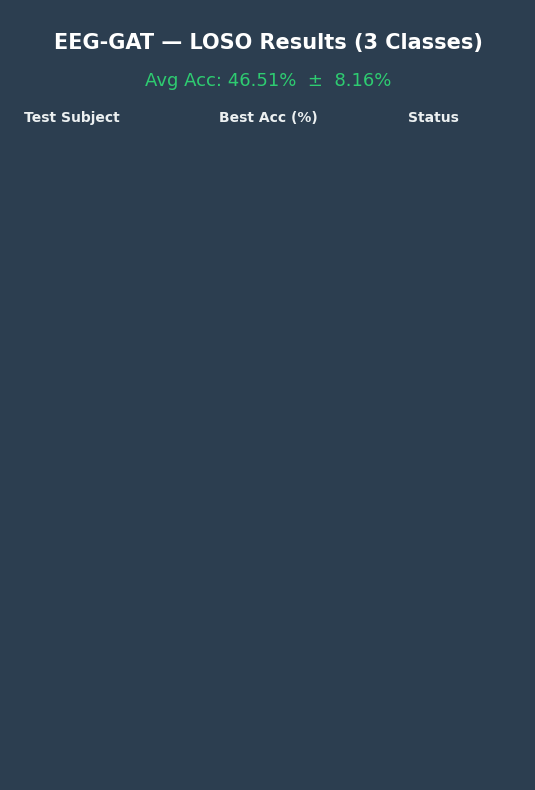

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
NUM_CLASSES = 3        
IN_CHANNELS = 5
NUM_NODES   = 62

EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-3
WD          = 1e-4
PATIENCE    = 20
THRESHOLD   = 0.5

EMOTION_LABELS = ["Neutral", "Sad+Fear", "Happy"]   


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — EEGGAT Model  (NUM_CLASSES=3 → no other change needed)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Label remapping ───────────────────────────────────────────────────
# SEED-IV original: 0=Neutral, 1=Sad, 2=Fear, 3=Happy
# New mapping     : 0=Neutral, 1=Sad+Fear, 2=Happy
LABEL_REMAP = {0: 0, 1: 1, 2: 1, 3: 2}

def remap_labels(labels: np.ndarray) -> np.ndarray:

    return np.vectorize(LABEL_REMAP.get)(labels)


def load_subjects(subject_ids, meta_info, dataset):
    all_x, all_y = [], []
    for sid in subject_ids:
        subject_df = meta_info[meta_info['subject_id'] == sid]
        for idx in subject_df.index.tolist():
            x, y = dataset[idx]
            all_x.append(x.squeeze())
            all_y.append(y)
    all_x = torch.stack(all_x).numpy()
    all_y = remap_labels(np.array(all_y))   # ← remap here
    return all_x, all_y


def build_edge_index(features, threshold=THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    return torch.tensor(np.stack([rows, cols]), dtype=torch.long)


def make_pyg_dataset(features, labels, edge_index):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        loss = criterion(out, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == batch_labels).sum().item()
        total      += batch_labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_trues, all_preds = [], []
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        pred = out.argmax(1)
        correct    += (pred == batch_labels).sum().item()
        total      += batch_labels.size(0)
        all_trues.extend(batch_labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
    return correct / total, all_trues, all_preds


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — LOSO Loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
meta_info    = dataset.info
all_subjects = sorted(dataset.info['subject_id'].unique())

loso_results = {}
loso_preds   = {}

print("=" * 60)
print("   LOSO — Leave-One-Subject-Out Evaluation  (3 Classes)")
print("   Neutral | Sad+Fear | Happy")
print("=" * 60)

for test_sid in all_subjects:

    train_sids = [s for s in all_subjects if s != test_sid]

    print(f"\n{'─'*60}")
    print(f"  Test Subject  : {test_sid}")
    print(f"  Train Subjects: {train_sids}")
    print(f"{'─'*60}")

    # ── Load + remap ──────────────────────────────────────────────────
    train_x, train_y = load_subjects(train_sids,  meta_info, dataset)
    test_x,  test_y  = load_subjects([test_sid],  meta_info, dataset)

    # ── Normalize ─────────────────────────────────────────────────────
    N_tr, C, B = train_x.shape
    scaler      = StandardScaler()
    train_x_norm = scaler.fit_transform(
                       train_x.reshape(N_tr, -1)
                   ).reshape(N_tr, C, B).astype(np.float32)

    N_te = test_x.shape[0]
    test_x_norm = scaler.transform(
                      test_x.reshape(N_te, -1)
                  ).reshape(N_te, C, B).astype(np.float32)

    print(f"  Train: {N_tr} samples | Labels dist: {np.bincount(train_y, minlength=3)}")
    print(f"  Test : {N_te} samples | Labels dist: {np.bincount(test_y,  minlength=3)}")

    # ── Graph ─────────────────────────────────────────────────────────
    edge_index = build_edge_index(train_x_norm)
    print(f"  Graph edges: {edge_index.shape[1]}")

    # ── Datasets & Loaders ────────────────────────────────────────────
    train_ds = make_pyg_dataset(train_x_norm, train_y, edge_index)
    test_ds  = make_pyg_dataset(test_x_norm,  test_y,  edge_index)

    class_counts  = np.bincount(train_y, minlength=3)   # ← minlength=3
    class_weights = 1. / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in train_y]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc   = 0.0
    best_trues = []
    best_preds = []
    counter    = 0

    for epoch in range(EPOCHS):
        loss, train_acc       = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, trues, preds = evaluate(model, test_loader)
        scheduler.step()

        print(f"  Epoch {epoch+1:03d} | Loss: {loss:.4f} | "
              f"Train: {train_acc*100:.2f}% | Test: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc   = val_acc
            best_trues = trues.copy()
            best_preds = preds.copy()
            counter    = 0
            torch.save(model.state_dict(),
                       f'best_loso_test{test_sid}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"\n  ✅ Subject {test_sid} Best Acc: {best_acc*100:.2f}%")
    loso_results[test_sid] = best_acc * 100
    loso_preds[test_sid]   = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(loso_results.values())
avg      = np.mean(all_accs)
std      = np.std(all_accs)

print(f"\n{'='*60}")
print(f"  LOSO FINAL RESULTS  (3 Classes: Neutral | Sad+Fear | Happy)")
print(f"{'='*60}")
print(f"  Average Accuracy : {avg:.2f}%")
print(f"  Std              : {std:.2f}%")
print(f"  Best  Subject    : {max(loso_results, key=loso_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(loso_results, key=loso_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"{'─'*60}")
for sid, acc in loso_results.items():
    print(f"  Subject {sid:02d} : {acc:.2f}%")
print(f"{'='*60}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DARK   = "#2c3e50"
GREEN  = "#2ecc71"
ORANGE = "#e67e22"
RED    = "#e74c3c"
BLUE   = "#3498db"
LIGHT  = "#ecf0f1"

def acc_color(acc):
    if acc >= 70: return GREEN
    if acc >= 50: return ORANGE
    return RED

NUM_SUBJECTS = len(loso_results)
accs         = [loso_results[i] for i in sorted(loso_results)]

# ── Figure 1: Summary Table + Bar Chart ──────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.08)

ax_t = fig.add_subplot(gs[0])
ax_t.set_facecolor(DARK)
ax_t.axis('off')
ax_t.text(0.5, 0.97, "EEG-GAT — LOSO Results (3 Classes)",
          ha='center', va='top', fontsize=15, fontweight='bold',
          color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.92, f"Avg Acc: {avg:.2f}%  ±  {std:.2f}%",
          ha='center', va='top', fontsize=13, color=GREEN,
          transform=ax_t.transAxes)

col_x     = [0.12, 0.50, 0.82]
col_names = ["Test Subject", "Best Acc (%)", "Status"]
row_start = 0.86
row_h     = 0.052

for cx, cl in zip(col_x, col_names):
    ax_t.text(cx, row_start, cl, ha='center', va='center',
              fontsize=10, fontweight='bold', color=LIGHT,
              transform=ax_t.transAxes)
ax_t.axhline(y=row_start - 0.015, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)

for i, sid in enumerate(sorted(loso_results)):
    acc    = loso_results[sid]
    y_pos  = row_start - row_h * (i + 1) - 0.015
    bg     = "#1a252f" if i % 2 == 0 else "#1e2f3d"
    status = "✅ Good" if acc >= 70 else ("⚠️ Moderate" if acc >= 50 else "❌ Poor")
    clr    = acc_color(acc)
    ax_t.add_patch(plt.Rectangle((0.04, y_pos - 0.018), 0.92, row_h - 0.004,
                                  transform=ax_t.transAxes, color=bg, zorder=0))
    ax_t.text(col_x[0], y_pos, f"Subject {sid:02d}", ha='center', va='center',
              fontsize=9.5, color='white', transform=ax_t.transAxes)
    ax_t.text(col_x[1], y_pos, f"{acc:.2f}", ha='center', va='center',
              fontsize=9.5, color=clr, fontweight='bold', transform=ax_t.transAxes)
    ax_t.text(col_x[2], y_pos, status, ha='center', va='center',
              fontsize=8.5, color=clr, transform=ax_t.transAxes)

y_bot = row_start - row_h * (NUM_SUBJECTS + 2) - 0.015
ax_t.axhline(y=y_bot + 0.03, xmin=0.05, xmax=0.95,
             color='gray', linewidth=0.8, transform=ax_t.transAxes)
ax_t.text(0.5, y_bot,
          f"Max: {max(accs):.2f}%   Min: {min(accs):.2f}%   Median: {np.median(accs):.2f}%",
          ha='center', va='center', fontsize=9, color=LIGHT,
          transform=ax_t.transAxes)

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor("#1a252f")
subjects = sorted(loso_results.keys())
colors   = [acc_color(loso_results[s]) for s in subjects]
bars     = ax_b.bar(subjects, accs, color=colors, width=0.6,
                    edgecolor='#2c3e50', linewidth=0.8, zorder=3)
for bar, acc in zip(bars, accs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f"{acc:.1f}", ha='center', va='bottom',
              fontsize=7.5, color='white', fontweight='bold')
ax_b.axhline(avg, color=BLUE, linewidth=1.5, linestyle='--',
             zorder=4, label=f"Avg = {avg:.2f}%")
ax_b.set_xlim(0.3, NUM_SUBJECTS + 0.7)
ax_b.set_ylim(0, 115)
ax_b.set_xticks(subjects)
ax_b.set_xticklabels([f"S{s}" for s in subjects], fontsize=9, color='white')
ax_b.set_yticks(range(0, 110, 10))
ax_b.set_yticklabels([f"{v}%" for v in range(0, 110, 10)], fontsize=9, color='white')
ax_b.set_xlabel("Test Subject (left-out)", fontsize=11, color='white', labelpad=8)
ax_b.set_ylabel("Best Test Accuracy (%)", fontsize=11, color='white', labelpad=8)
ax_b.set_title("LOSO — Per-Subject Test Accuracy (3 Classes)",
               fontsize=13, color='white', pad=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#2c3e50', labelcolor='white', edgecolor='gray')
ax_b.grid(axis='y', alpha=0.2, color='gray', zorder=0)
ax_b.tick_params(colors='white')
for spine in ax_b.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle("EEG-GAT — Subject-Independent (LOSO)\n"
             "SEED-IV | DE Features | 3 Classes | 15 Iterations\n"
             "Neutral  |  Sad+Fear  |  Happy",
             fontsize=14, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("loso_summary.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: loso_summary.png")


# ── Figure 2: Confusion Matrices (5×3) — 3×3 each ───────────────────
cmap_cm = LinearSegmentedColormap.from_list(
    "eeg", ["#0d1b2a", "#1b4f72", "#2980b9", "#58d68d", "#f4d03f"]
)
fig2, axes = plt.subplots(3, 5, figsize=(22, 14), facecolor=DARK)
fig2.suptitle("Confusion Matrices — LOSO\n"
              "EEG-GAT | SEED-IV | Neutral / Sad+Fear / Happy",
              fontsize=14, color='white', fontweight='bold', y=1.01)

CLASS_LABELS = ["Neu", "S+F", "Hap"]   # ← 3 labels

for idx, sid in enumerate(sorted(loso_results)):
    row, col = divmod(idx, 5)
    ax       = axes[row][col]
    ax.set_facecolor("#0d1b2a")
    acc      = loso_results[sid]

    trues, preds = loso_preds[sid]
    cm           = confusion_matrix(trues, preds, labels=[0, 1, 2])   # ← 3 classes
    cm_norm      = cm.astype(float)
    rs           = cm_norm.sum(axis=1, keepdims=True)
    rs[rs == 0]  = 1
    cm_norm      = cm_norm / rs

    ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(3):          # ← 3
        for c in range(3):      # ← 3
            color = 'white' if cm_norm[r, c] < 0.6 else 'black'
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_LABELS, fontsize=7, color='white', rotation=30)
    ax.set_yticklabels(CLASS_LABELS, fontsize=7, color='white')
    status = "✅" if acc >= 70 else ("⚠️" if acc >= 50 else "❌")
    ax.set_title(f"{status} Test S{sid}  —  {acc:.1f}%",
                 fontsize=9, color=acc_color(acc), fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig("loso_confusion_matrices.png", dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Saved: loso_confusion_matrices.png")




In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
NUM_CLASSES = 2          # ← binary
IN_CHANNELS = 5
NUM_NODES   = 62

EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-3
WD          = 1e-4
PATIENCE    = 20
THRESHOLD   = 0.5

EMOTION_LABELS = ["Negative (Sad+Fear+Neutral)", "Happy"]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — EEGGAT Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Label remapping ───────────────────────────────────────────────────
# SEED-IV original: 0=Neutral, 1=Sad, 2=Fear, 3=Happy
# New mapping     : 0=Negative (Sad+Fear+Neutral), 1=Happy
LABEL_REMAP = {0: 0, 1: 0, 2: 0, 3: 1}

def remap_labels(labels: np.ndarray) -> np.ndarray:
    return np.vectorize(LABEL_REMAP.get)(labels)


def load_subjects(subject_ids, meta_info, dataset):
    all_x, all_y = [], []
    for sid in subject_ids:
        subject_df = meta_info[meta_info['subject_id'] == sid]
        for idx in subject_df.index.tolist():
            x, y = dataset[idx]
            all_x.append(x.squeeze())
            all_y.append(y)
    all_x = torch.stack(all_x).numpy()
    all_y = remap_labels(np.array(all_y))   # ← remap
    return all_x, all_y


def build_edge_index(features, threshold=THRESHOLD):
    mean_feat = features.mean(axis=0)
    corr      = np.corrcoef(mean_feat)
    corr      = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    return torch.tensor(np.stack([rows, cols]), dtype=torch.long)


def make_pyg_dataset(features, labels, edge_index):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(int(labels[i]), dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([data.y for data in batch_list])
    return Batch.from_data_list(batch_list), labels


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        loss = criterion(out, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == batch_labels).sum().item()
        total      += batch_labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_trues, all_preds = [], []
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        pred = out.argmax(1)
        correct    += (pred == batch_labels).sum().item()
        total      += batch_labels.size(0)
        all_trues.extend(batch_labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
    return correct / total, all_trues, all_preds


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — LOSO Loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
meta_info    = dataset.info
all_subjects = sorted(dataset.info['subject_id'].unique())

loso_results = {}
loso_preds   = {}

print("=" * 60)
print("   LOSO — Binary Classification")
print("   Negative (Sad+Fear+Neutral)  vs  Happy")
print("=" * 60)

for test_sid in all_subjects:

    train_sids = [s for s in all_subjects if s != test_sid]

    print(f"\n{'─'*60}")
    print(f"  Test Subject  : {test_sid}")
    print(f"  Train Subjects: {train_sids}")
    print(f"{'─'*60}")

    # ── Load + remap ──────────────────────────────────────────────────
    train_x, train_y = load_subjects(train_sids, meta_info, dataset)
    test_x,  test_y  = load_subjects([test_sid], meta_info, dataset)

    # ── Normalize ─────────────────────────────────────────────────────
    N_tr, C, B = train_x.shape
    scaler      = StandardScaler()
    train_x_norm = scaler.fit_transform(
                       train_x.reshape(N_tr, -1)
                   ).reshape(N_tr, C, B).astype(np.float32)

    N_te = test_x.shape[0]
    test_x_norm = scaler.transform(
                      test_x.reshape(N_te, -1)
                  ).reshape(N_te, C, B).astype(np.float32)

    # ── Class distribution ────────────────────────────────────────────
    counts_tr = np.bincount(train_y, minlength=2)
    counts_te = np.bincount(test_y,  minlength=2)
    print(f"  Train: {N_tr} | Negative={counts_tr[0]}  Happy={counts_tr[1]}")
    print(f"  Test : {N_te} | Negative={counts_te[0]}  Happy={counts_te[1]}")

    # ── Graph ─────────────────────────────────────────────────────────
    edge_index = build_edge_index(train_x_norm)
    print(f"  Graph edges: {edge_index.shape[1]}")

    # ── Datasets ──────────────────────────────────────────────────────
    train_ds = make_pyg_dataset(train_x_norm, train_y, edge_index)
    test_ds  = make_pyg_dataset(test_x_norm,  test_y,  edge_index)

    # ── WeightedRandomSampler ─────────────────────────────────────────
    class_counts  = np.bincount(train_y, minlength=2)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_w      = [class_weights[y] for y in train_y]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model = EEGGAT().to(device)

    # ── class_weight في Loss أيضاً (الطبقة الثانية من الحماية) ────────
    loss_class_w = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion    = nn.CrossEntropyLoss(
                       weight=loss_class_w,
                       label_smoothing=0.1
                   )

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc   = 0.0
    best_trues = []
    best_preds = []
    counter    = 0

    for epoch in range(EPOCHS):
        loss, train_acc       = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, trues, preds = evaluate(model, test_loader)
        scheduler.step()

        print(f"  Epoch {epoch+1:03d} | Loss: {loss:.4f} | "
              f"Train: {train_acc*100:.2f}% | Test: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc   = val_acc
            best_trues = trues.copy()
            best_preds = preds.copy()
            counter    = 0
            torch.save(model.state_dict(),
                       f'best_loso_test{test_sid}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"\n  ✅ Subject {test_sid} Best Acc: {best_acc*100:.2f}%")
    loso_results[test_sid] = best_acc * 100
    loso_preds[test_sid]   = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(loso_results.values())
avg      = np.mean(all_accs)
std      = np.std(all_accs)

print(f"\n{'='*60}")
print(f"  LOSO FINAL — Binary: Negative vs Happy")
print(f"{'='*60}")
print(f"  Average Accuracy : {avg:.2f}%")
print(f"  Std              : {std:.2f}%")
print(f"  Best  Subject    : {max(loso_results, key=loso_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(loso_results, key=loso_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"{'─'*60}")
for sid, acc in loso_results.items():
    print(f"  Subject {sid:02d} : {acc:.2f}%")
print(f"{'='*60}")




   LOSO — Binary Classification
   Negative (Sad+Fear+Neutral)  vs  Happy

────────────────────────────────────────────────────────────
  Test Subject  : 1
  Train Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
────────────────────────────────────────────────────────────


KeyboardInterrupt: 

In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   EEG-GAT — Subject-Dependent                                        ║
# ║   SEED-IV | DE + DASM Features (10) | 4 Classes | 80/20 Split        ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 1 — Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os
import shutil
import numpy as np
import pywt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch_geometric.nn   import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import confusion_matrix
from sklearn.model_selection import train_test_split
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from torcheeg import transforms
from torcheeg.datasets import SEEDIVDataset


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 2 — Dataset: Preprocessing + Feature Extraction
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
if os.path.exists('./tmp_out/seed_iv_advanced_features'):
    shutil.rmtree('./tmp_out/seed_iv_advanced_features')
    print("Old cache deleted. Data will be re-processed.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── EEG Cleaning ──────────────────────────────────────────────────────
def BandPassFilter(eeg_data):
    b, a = signal.butter(4, Wn=[1.0, 75.0], btype='bandpass', fs=200)
    return signal.filtfilt(b, a, eeg_data, axis=-1)

def Notch(eeg_data):
    b, a = signal.iirnotch(w0=50.0, Q=30.0, fs=200)
    return signal.filtfilt(b, a, eeg_data, axis=-1)

# ── Channel Pairs (Left / Right hemisphere) ───────────────────────────
LEFT_CH  = [0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26,
            28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52]
RIGHT_CH = [1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27,
            29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53]

# ── Feature Helpers ───────────────────────────────────────────────────
def pad_to_62(small_matrix):
    """Pad (27, 5) asymmetry matrix → (62, 5) by zero-filling."""
    padded = np.zeros((62, 5))
    padded[:27, :] = small_matrix
    return padded

def calculate_de(coeffs):
    variance = np.var(coeffs, ddof=1)
    return 0.5 * np.log2(2 * np.pi * np.exp(1) * (variance + 1e-10))

# ── Main Feature Function: DE + DASM only ────────────────────────────
def seed_iv_advanced_features_fn(x):
    """
    Input : (62, T) raw EEG
    Output: (62, 10)
              - DE   cols 0-4   (62 × 5)
              - DASM cols 5-9   (62 × 5, padded)
    """
    num_channels = x.shape[0]
    num_bands    = 5
    de_matrix    = np.zeros((num_channels, num_bands))

    for ch in range(num_channels):
        coeffs = pywt.wavedec(x[ch], 'db4', level=5)
        for i in range(1, 6):
            de_matrix[ch, i - 1] = calculate_de(coeffs[i])

    # DASM: Left hemisphere DE − Right hemisphere DE
    dasm_small = de_matrix[LEFT_CH] - de_matrix[RIGHT_CH]   # (27, 5)
    dasm_62    = pad_to_62(dasm_small)                       # (62, 5)

    final_features = np.concatenate([
        de_matrix,   # (62, 5)
        dasm_62,     # (62, 5)
    ], axis=1)       # → (62, 10)

    return final_features.astype(np.float32)

# ── Windowing ─────────────────────────────────────────────────────────
window          = 800
overlap_ratio   = 0.3
step            = int(window * (1 - overlap_ratio))
overlap_samples = window - step

# ── Transform Pipeline ────────────────────────────────────────────────
t_transform = transforms.Compose([
    transforms.Lambda(BandPassFilter),
    transforms.Lambda(Notch),
    transforms.BaselineRemoval(),
    transforms.Lambda(seed_iv_advanced_features_fn),
    transforms.MeanStdNormalize(),
    transforms.To2d(),
    transforms.ToTensor()
])

# ── Build Dataset ─────────────────────────────────────────────────────
dataset = SEEDIVDataset(
    io_path          = './tmp_out/seed_iv_advanced_features',
    root_path        = '/kaggle/input/seed-iv/eeg_raw_data',
    offline_transform = t_transform,
    label_transform  = transforms.Compose([
        transforms.Select('emotion'),
    ]),
    chunk_size  = window,
    overlap     = overlap_samples,
    io_mode     = 'memory',
    num_worker  = 1
)

x, y = dataset[0]
print(f"Features shape: {x.shape}")   # → torch.Size([1, 62, 10])


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 3 — Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIDDEN      = 64
HEADS       = 4
DROPOUT     = 0.3
NUM_CLASSES = 4          # Neutral / Sad / Fear / Happy
IN_CHANNELS = 10         # DE×5 + DASM×5
NUM_NODES   = 62

EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 1e-3
WD          = 1e-4
PATIENCE    = 20
THRESHOLD   = 0.5
TEST_SIZE   = 0.2        # 80% train / 20% test
RANDOM_SEED = 42

EMOTION_LABELS = ["Neutral", "Sad", "Fear", "Happy"]


ImportError: scipy.special._ufuncs_cxx does not export expected C variable _export_expit

In [ ]:


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 4 — EEGGAT Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EEGGAT(nn.Module):
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden      = HIDDEN,
                 heads       = HEADS,
                 num_classes = NUM_CLASSES,
                 dropout     = DROPOUT):
        super().__init__()
        self.drop_rate = dropout          # ← غير من self.dropout

        self.gat1 = GATConv(in_channels,    hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.dropout(x, p=self.drop_rate, training=self.training)   # ← drop_rate
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.drop_rate, training=self.training)   # ← drop_rate
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        x = F.dropout(x, p=self.drop_rate, training=self.training)   # ← drop_rate
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        x = global_mean_pool(x, batch)
        return self.classifier(x)



# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 5 — Helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def load_one_subject(subject_id, meta_info, dataset):
    """Load all samples for a single subject → (N, 62, 10)."""
    subject_df = meta_info[meta_info['subject_id'] == subject_id]
    all_x, all_y = [], []
    for idx in subject_df.index.tolist():
        x, y = dataset[idx]
        all_x.append(x.squeeze(0).numpy())   # (1,62,10) → (62,10)
        all_y.append(int(y))
    return np.stack(all_x), np.array(all_y)   # (N,62,10), (N,)


def build_edge_index(features, threshold=THRESHOLD):
    """Build adjacency from correlation of train features."""
    mean_feat  = features.mean(axis=0)          # (62, 10)
    corr       = np.corrcoef(mean_feat)          # (62, 62)
    corr       = np.nan_to_num(corr)
    rows, cols = np.where(
        (np.abs(corr) >= threshold) & (~np.eye(62, dtype=bool))
    )
    return torch.tensor(np.stack([rows, cols]), dtype=torch.long)


def make_pyg_dataset(features, labels, edge_index):
    return [
        Data(
            x          = torch.tensor(features[i], dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(labels[i],   dtype=torch.long)
        )
        for i in range(len(features))
    ]


def collate_pyg(batch_list):
    labels = torch.stack([d.y for d in batch_list])
    return Batch.from_data_list(batch_list), labels


def make_weighted_sampler(labels, num_classes):
    counts   = np.bincount(labels, minlength=num_classes)
    class_w  = 1.0 / (counts + 1e-6)
    sample_w = [class_w[y] for y in labels]
    return WeightedRandomSampler(sample_w, len(sample_w), replacement=True)


def make_loss_weights(labels, num_classes, dev):
    counts  = np.bincount(labels, minlength=num_classes)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float).to(dev)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        loss = criterion(out, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == batch_labels).sum().item()
        total      += batch_labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_trues, all_preds = [], []
    for batch_graph, batch_labels in loader:
        batch_graph  = batch_graph.to(device)
        batch_labels = batch_labels.to(device)
        out  = model(batch_graph.x, batch_graph.edge_index, batch_graph.batch)
        pred = out.argmax(1)
        correct    += (pred == batch_labels).sum().item()
        total      += batch_labels.size(0)
        all_trues.extend(batch_labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
    return correct / total, all_trues, all_preds


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 6 — Subject-Dependent Training Loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
meta_info    = dataset.info
all_subjects = sorted(meta_info['subject_id'].unique())   # [1..15]

sd_results = {}   # {subject_id: best_acc}
sd_preds   = {}   # {subject_id: (trues, preds)}

print("=" * 60)
print("   Subject-Dependent Evaluation")
print(f"   SEED-IV | DE+DASM (10 features) | {NUM_CLASSES} Classes | 80/20 Split")
print("=" * 60)

for sid in all_subjects:

    print(f"\n{'─'*60}")
    print(f"  Subject : {sid}")
    print(f"{'─'*60}")

    # ── Load ──────────────────────────────────────────────────────────
    X, y = load_one_subject(sid, meta_info, dataset)
    # X: (N, 62, 10)   y: (N,)

    # ── Stratified 80/20 split ────────────────────────────────────────
    indices = np.arange(len(y))
    tr_idx, te_idx = train_test_split(
        indices,
        test_size    = TEST_SIZE,
        random_state = RANDOM_SEED,
        stratify     = y
    )
    train_x, train_y = X[tr_idx], y[tr_idx]
    test_x,  test_y  = X[te_idx], y[te_idx]

    # ── Normalize — fit on train only ─────────────────────────────────
    N_tr, C, F = train_x.shape
    scaler      = StandardScaler()
    train_x_norm = scaler.fit_transform(
                       train_x.reshape(N_tr, -1)
                   ).reshape(N_tr, C, F).astype(np.float32)

    N_te = test_x.shape[0]
    test_x_norm = scaler.transform(
                      test_x.reshape(N_te, -1)
                  ).reshape(N_te, C, F).astype(np.float32)

    counts_tr = np.bincount(train_y, minlength=NUM_CLASSES)
    counts_te = np.bincount(test_y,  minlength=NUM_CLASSES)
    print(f"  Train: {N_tr} samples | {counts_tr}")
    print(f"  Test : {N_te} samples | {counts_te}")

    # ── Graph — built from train only ─────────────────────────────────
    edge_index = build_edge_index(train_x_norm)
    print(f"  Graph edges: {edge_index.shape[1]}")

    # ── Datasets & Loaders ────────────────────────────────────────────
    train_ds = make_pyg_dataset(train_x_norm, train_y, edge_index)
    test_ds  = make_pyg_dataset(test_x_norm,  test_y,  edge_index)

    sampler = make_weighted_sampler(train_y, NUM_CLASSES)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, collate_fn=collate_pyg)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_pyg)

    # ── Model ─────────────────────────────────────────────────────────
    model     = EEGGAT().to(device)
    loss_w    = make_loss_weights(train_y, NUM_CLASSES, device)
    criterion = nn.CrossEntropyLoss(weight=loss_w, label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc   = 0.0
    best_trues = []
    best_preds = []
    counter    = 0

    # ── Epoch Loop ────────────────────────────────────────────────────
    for epoch in range(EPOCHS):
        loss, train_acc       = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, trues, preds = evaluate(model, test_loader)
        scheduler.step()

        print(f"  Epoch {epoch+1:03d} | Loss: {loss:.4f} | "
              f"Train: {train_acc*100:.2f}% | Test: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc   = val_acc
            best_trues = trues.copy()
            best_preds = preds.copy()
            counter    = 0
            torch.save(model.state_dict(), f'best_sd_subject{sid}.pt')
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"\n  ✅ Subject {sid} Best Acc: {best_acc*100:.2f}%")
    sd_results[sid] = best_acc * 100
    sd_preds[sid]   = (best_trues, best_preds)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Cell 7 — Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
all_accs = list(sd_results.values())
avg      = np.mean(all_accs)
std      = np.std(all_accs)

print(f"\n{'='*60}")
print(f"  SUBJECT-DEPENDENT FINAL RESULTS")
print(f"  DE + DASM | 4 Classes | 80/20 Split")
print(f"{'='*60}")
print(f"  Average Accuracy : {avg:.2f}%")
print(f"  Std              : {std:.2f}%")
print(f"  Best  Subject    : {max(sd_results, key=sd_results.get)}"
      f"  ({max(all_accs):.2f}%)")
print(f"  Worst Subject    : {min(sd_results, key=sd_results.get)}"
      f"  ({min(all_accs):.2f}%)")
print(f"{'─'*60}")
for sid, acc in sd_results.items():
    print(f"  Subject {sid:02d} : {acc:.2f}%")
print(f"{'='*60}")


